Figure saved successfully.


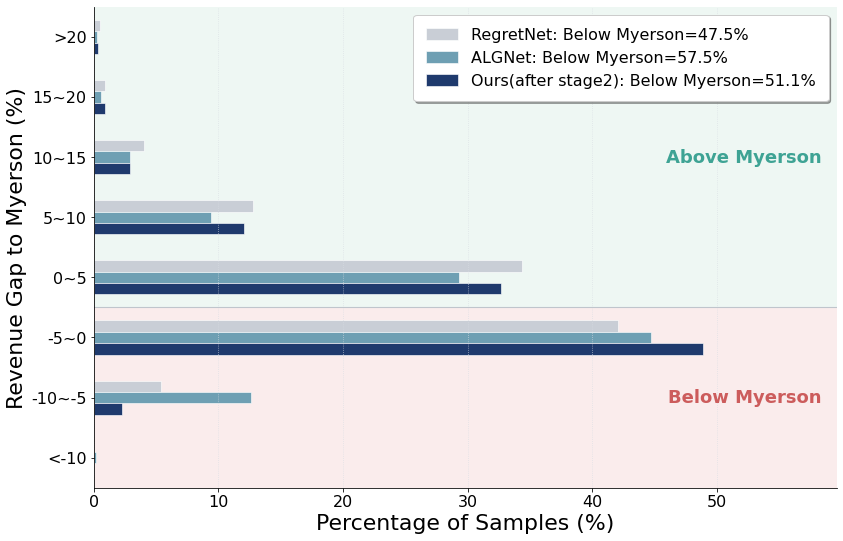

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Device and model loading
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Initializing seeds
torch.manual_seed(4)
np.random.seed(4)

# Load the proposed model.
# If the checkpoint is a MixedWrapper, use only its pure neural student (.base)
# for profile-level evaluation and plotting.
mechanismm = torch.load("510stage2.pth", map_location=device).to(device)
mechanism = mechanismm.base if hasattr(mechanismm, "base") else mechanismm
mechanism = mechanism.to(device)
mechanism.eval()


# ============================================================
# Plot style
# ============================================================
COLOR_OURS = "#1F3A6D"
COLOR_ALGNET = "#6E9FB3"
COLOR_REGRETNET = "#C9CED6"

BG_ABOVE = "#EEF7F3"
BG_BELOW = "#FAECEC"
GRID_COLOR = "#D8DDE3"

TEXT_ABOVE = "#3EA394"
TEXT_BELOW = "#CC5C5C"

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})


# ============================================================
# 5x10 raw 5% bucket data for RegretNet and ALGNet
# ============================================================
# Note:
# The RegretNet and ALGNet bucket counts below are not copied from
# the revenue tables in the original papers, nor are they generated
# by this plotting script.
#
# We first evaluated the actual trained RegretNet / ALGNet models
# profile by profile under the same test distribution, computed each
# profile's revenue gap relative to item-wise Myerson, and then counted
# samples in 5% gap intervals.
#
# For plotting convenience, the resulting bucket counts are manually
# recorded here as fixed arrays.

REGRETNET_5X10_UNDERPERF = [
    4205, 542, 1, 0, 0, 0, 0, 0, 0, 0, 0
]
REGRETNET_5X10_OVERPERF = [
    3434, 1277, 401, 92, 33, 7, 5, 1, 1, 1, 0
]

ALGNET_5X10_UNDERPERF = [
    4471, 1261, 19
]
ALGNET_5X10_OVERPERF = [
    2933, 943, 290, 59, 21, 3
]


# ============================================================
# Item-wise Myerson revenue
# ============================================================
def calculate_myerson_revenue(vals, reserve=0.5):
    """
    Compute item-wise Myerson revenue for Uniform[0,1] valuations.

    vals: tensor with shape [batch, n_bidders, n_items].
    For each item, the winner pays max(second-highest bid, reserve)
    if the highest bid is above the reserve.
    """
    dev = vals.device
    v_max, _ = torch.max(vals, dim=1)
    v_top2, _ = torch.topk(vals, 2, dim=1)
    v_second = v_top2[:, 1, :]

    reserve_t = torch.tensor(reserve, device=dev, dtype=vals.dtype)
    zero_t = torch.tensor(0.0, device=dev, dtype=vals.dtype)

    item_payments = torch.where(
        v_max > reserve_t,
        torch.maximum(v_second, reserve_t),
        zero_t
    )
    return item_payments.sum(dim=-1)


def total_revenue(payment):
    """
    Compute total revenue per profile, compatible with both bidder-level
    payment [B, n_bidders] and item-wise payment [B, n_bidders, n_items].
    """
    if payment.dim() == 1:
        return payment
    return payment.reshape(payment.shape[0], -1).sum(dim=-1)


def compute_pct_ours(model, nAgent, nObject, nBatch=10000, reserve=0.5):
    """
    Compute the percentage revenue gap of the proposed neural model
    relative to item-wise Myerson on sampled profiles.
    """
    net = model.base if hasattr(model, "base") else model
    net.eval()
    dev = next(net.parameters()).device

    true_vals = torch.rand(nBatch, nAgent, nObject, device=dev)

    with torch.no_grad():
        _, pay = net(true_vals)
        rev = total_revenue(pay).cpu().numpy()
        rev_myr = calculate_myerson_revenue(true_vals, reserve=reserve).cpu().numpy()

    return (rev - rev_myr) / np.maximum(rev_myr, 1e-9) * 100.0


# ============================================================
# 5% bucket helpers
# ============================================================
# Display bins:
# positive side: 0~5, 5~10, 10~15, 15~20, >20
# negative side: 0~5, 5~10, >10

def _below_myerson_rate(under_counts, over_counts):
    """Compute the fraction of profiles whose revenue is below Myerson."""
    under = float(np.sum(under_counts))
    total = under + float(np.sum(over_counts))
    return 0.0 if total <= 0 else 100.0 * under / total


def _compress_under_counts_5pct(counts):
    """
    Compress negative-side counts into:
    [0~5), [5~10), and >=10.
    """
    counts = np.asarray(counts, dtype=int)
    regular = []
    for i in range(2):
        regular.append(counts[i] if i < len(counts) else 0)
    tail = int(np.sum(counts[2:])) if len(counts) > 2 else 0
    return np.array([*regular, tail], dtype=int)


def _compress_over_counts_5pct(counts):
    """
    Compress positive-side counts into:
    [0~5), [5~10), [10~15), [15~20), and >=20.
    """
    counts = np.asarray(counts, dtype=int)
    regular = []
    for i in range(4):
        regular.append(counts[i] if i < len(counts) else 0)
    tail = int(np.sum(counts[4:])) if len(counts) > 4 else 0
    return np.array([*regular, tail], dtype=int)


def _bucket_counts_from_percentages_5pct(pct):
    """
    Convert percentage revenue gaps into display buckets.

    under = [0~5, 5~10, >10]
    over  = [0~5, 5~10, 10~15, 15~20, >20]
    """
    under = np.zeros(3, dtype=int)
    over = np.zeros(5, dtype=int)

    neg_vals = -pct[pct < 0]
    pos_vals = pct[pct >= 0]

    neg_idx = np.floor(neg_vals / 5).astype(int)
    pos_idx = np.floor(pos_vals / 5).astype(int)

    neg_idx = np.clip(neg_idx, 0, 2)
    pos_idx = np.clip(pos_idx, 0, 4)

    for k in neg_idx:
        under[k] += 1
    for k in pos_idx:
        over[k] += 1

    return under, over


# ============================================================
# Main plot
# ============================================================
def plot_5x10_comparison_bar_5pct(
    model,
    nAgent=5,
    nObject=10,
    nBatch=10000,
    reserve=0.5,
    filename="comparison_5x10_bar_5pct_cap20_10"
):
    """
    Plot the profile-level revenue gap distribution relative to item-wise
    Myerson for RegretNet, ALGNet, and the proposed model.
    """
    pct_ours = compute_pct_ours(model, nAgent, nObject, nBatch=nBatch, reserve=reserve)

    regret_under = _compress_under_counts_5pct(REGRETNET_5X10_UNDERPERF)
    regret_over = _compress_over_counts_5pct(REGRETNET_5X10_OVERPERF)

    alg_under = _compress_under_counts_5pct(ALGNET_5X10_UNDERPERF)
    alg_over = _compress_over_counts_5pct(ALGNET_5X10_OVERPERF)

    ours_under, ours_over = _bucket_counts_from_percentages_5pct(pct_ours)

    below_regret = _below_myerson_rate(regret_under, regret_over)
    below_alg = _below_myerson_rate(alg_under, alg_over)
    below_ours = float(np.mean(pct_ours < 0) * 100.0)

    regret_total = float(np.sum(regret_under) + np.sum(regret_over))
    alg_total = float(np.sum(alg_under) + np.sum(alg_over))
    ours_total = float(np.sum(ours_under) + np.sum(ours_over))

    # Above Myerson: >20, 15~20, 10~15, 5~10, 0~5.
    regret_pos = np.array([regret_over[-1], *regret_over[:-1][::-1]], dtype=float)
    alg_pos = np.array([alg_over[-1], *alg_over[:-1][::-1]], dtype=float)
    ours_pos = np.array([ours_over[-1], *ours_over[:-1][::-1]], dtype=float)

    # Below Myerson: -5~0, -10~-5, <-10.
    regret_neg = np.array(regret_under, dtype=float)
    alg_neg = np.array(alg_under, dtype=float)
    ours_neg = np.array(ours_under, dtype=float)

    regret_pct_bins = np.concatenate([regret_pos, regret_neg]) / regret_total * 100.0
    alg_pct_bins = np.concatenate([alg_pos, alg_neg]) / alg_total * 100.0
    ours_pct_bins = np.concatenate([ours_pos, ours_neg]) / ours_total * 100.0

    bin_labels = [
        ">20", "15~20", "10~15", "5~10", "0~5",
        "-5~0", "-10~-5", "<-10"
    ]

    spacing = 1.32
    y = np.arange(len(bin_labels)) * spacing
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(12, 7.8))

    split_y = (y[4] + y[5]) / 2
    top_edge = y[0] - spacing / 2
    bottom_edge = y[-1] + spacing / 2

    ax.axhspan(top_edge, split_y, color=BG_ABOVE, alpha=1.0, zorder=0)
    ax.axhspan(split_y, bottom_edge, color=BG_BELOW, alpha=1.0, zorder=0)

    ax.barh(
        y - bar_h,
        regret_pct_bins,
        height=bar_h,
        color=COLOR_REGRETNET,
        edgecolor="white",
        linewidth=0.6,
        label=f"RegretNet: Below Myerson={below_regret:.1f}%"
    )
    ax.barh(
        y,
        alg_pct_bins,
        height=bar_h,
        color=COLOR_ALGNET,
        edgecolor="white",
        linewidth=0.6,
        label=f"ALGNet: Below Myerson={below_alg:.1f}%"
    )
    ax.barh(
        y + bar_h,
        ours_pct_bins,
        height=bar_h,
        color=COLOR_OURS,
        edgecolor="white",
        linewidth=0.6,
        label=f"Ours(after stage2): Below Myerson={below_ours:.1f}%"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(bin_labels, fontsize=16)
    ax.set_ylim(bottom_edge, top_edge)
    ax.margins(y=0)

    ax.set_xlabel("Percentage of Samples (%)", fontsize=22)
    ax.set_ylabel("Revenue Gap to Myerson (%)", fontsize=22)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    max_x = max(
        np.max(regret_pct_bins),
        np.max(alg_pct_bins),
        np.max(ours_pct_bins)
    ) * 1.22
    ax.set_xlim(0, max_x)

    ax.axhline(split_y, color="#BFC5CC", linewidth=1.1)

    y_above = 0.5 * (y[0] + y[4])
    y_below = 0.5 * (y[5] + y[-1])

    ax.text(
        max_x * 0.98, y_above, "Above Myerson",
        color=TEXT_ABOVE, ha="right", va="center",
        fontsize=18, fontweight="bold"
    )
    ax.text(
        max_x * 0.98, y_below, "Below Myerson",
        color=TEXT_BELOW, ha="right", va="center",
        fontsize=18, fontweight="bold"
    )

    ax.grid(axis="x", linestyle=":", color=GRID_COLOR, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper right",
        frameon=True,
        shadow=True,
        borderpad=0.8,
        fontsize=16
    )

    plt.tight_layout()
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")
    print("Figure saved successfully.")
    plt.show()


plot_5x10_comparison_bar_5pct(
    mechanism,
    nAgent=5,
    nObject=10,
    nBatch=10000,
    filename="comparison_5x10_bar_5pct_cap20_10"
)

图片保存成功。


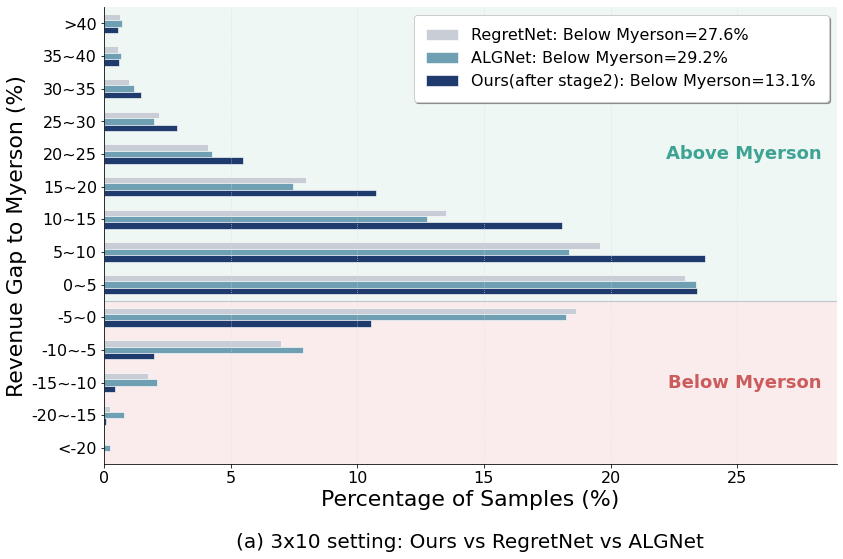

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Initializing seeds
torch.manual_seed(4)
np.random.seed(4)
mechanismm = torch.load("310stage2.pt", map_location=device).to(device)
mechanism = mechanismm.base if hasattr(mechanismm, "base") else mechanismm
mechanism = mechanism.to(device)
mechanism.eval()

# =============================
# Paper-style colors
# =============================
COLOR_OURS = "#1F3A6D"        # deep navy
COLOR_ALGNET = "#6E9FB3"      # muted blue-teal
COLOR_REGRETNET = "#C9CED6"   # soft cool gray

BG_ABOVE = "#EEF7F3"          # very light green
BG_BELOW = "#FAECEC"          # very light red
GRID_COLOR = "#D8DDE3"

TEXT_ABOVE = "#3EA394"
TEXT_BELOW = "#CC5C5C"

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

# =============================
# 3x10 raw 5% bucket data from user
# =============================
# RegretNet underperformance:
# [0,5), [5,10), [10,15), [15,20), [20,25), ..., [80,+inf)
REGRETNET_3X10_UNDERPERF = [
    1862, 698, 172, 22, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]

# RegretNet overperformance:
# [0,5), [5,10), ..., [75,80), [80,+inf)
REGRETNET_3X10_OVERPERF = [
    2293, 1957, 1350, 798, 411, 217, 99, 54, 35, 12, 8, 5, 1, 0, 2, 1, 0
]

# ALGNet underperformance:
# [0,5), [5,10), ..., [30,35)
ALGNET_3X10_UNDERPERF = [
    1823, 786, 208, 79, 18, 4, 2
]

# ALGNet overperformance:
# [0,5), [5,10), ..., [100,105)
ALGNET_3X10_OVERPERF = [
    2338, 1836, 1276, 748, 426, 198, 119, 66, 41, 18,
    6, 4, 0, 1, 1, 0, 1, 0, 0, 0, 1
]


# =============================
# Myerson revenue
# =============================
def calculate_myerson_revenue(vals, reserve=0.5):
    dev = vals.device
    v_max, _ = torch.max(vals, dim=1)
    v_top2, _ = torch.topk(vals, 2, dim=1)
    v_second = v_top2[:, 1, :]
    reserve_t = torch.tensor(reserve, device=dev)
    zero_t = torch.tensor(0.0, device=dev)

    item_payments = torch.where(
        v_max > reserve_t,
        torch.max(v_second, reserve_t),
        zero_t
    )
    return item_payments.sum(dim=-1)


def compute_pct_ours(model, nAgent, nObject, nBatch=10000, reserve=0.5):
    net = model.base if hasattr(model, "base") else model
    net.eval()
    dev = next(net.parameters()).device

    true_vals = torch.rand(nBatch, nAgent, nObject, device=dev)
    with torch.no_grad():
        _, pay = net(true_vals)
        rev = pay.sum(dim=-1).cpu().numpy()
        rev_myr = calculate_myerson_revenue(true_vals, reserve=reserve).cpu().numpy()

    return (rev - rev_myr) / np.maximum(rev_myr, 1e-9) * 100.0


# =============================
# Helpers
# display bins:
# positive: 0~5, 5~10, ..., 35~40, >40
# negative: 0~5, 5~10, 10~15, 15~20, >20
# =============================
def _below_myerson_rate(under_counts, over_counts):
    under = float(np.sum(under_counts))
    total = under + float(np.sum(over_counts))
    return 0.0 if total <= 0 else 100.0 * under / total


def _compress_under_counts_5pct(counts):
    """
    Negative side display bins:
    [0~5), [5~10), [10~15), [15~20), tail >=20
    """
    counts = np.asarray(counts, dtype=int)
    regular = []
    for i in range(4):
        regular.append(counts[i] if i < len(counts) else 0)
    tail = int(np.sum(counts[4:])) if len(counts) > 4 else 0
    return np.array([*regular, tail], dtype=int)


def _compress_over_counts_5pct(counts):
    """
    Positive side display bins:
    [0~5), [5~10), [10~15), [15~20), [20~25),
    [25~30), [30~35), [35~40), tail >=40
    """
    counts = np.asarray(counts, dtype=int)
    regular = []
    for i in range(8):
        regular.append(counts[i] if i < len(counts) else 0)
    tail = int(np.sum(counts[8:])) if len(counts) > 8 else 0
    return np.array([*regular, tail], dtype=int)


def _bucket_counts_from_percentages_5pct(pct):
    """
    Ours:
    under = [0~5, 5~10, 10~15, 15~20, >20]
    over  = [0~5, 5~10, 10~15, 15~20, 20~25, 25~30, 30~35, 35~40, >40]
    """
    under = np.zeros(5, dtype=int)
    over = np.zeros(9, dtype=int)

    neg_vals = -pct[pct < 0]
    pos_vals = pct[pct >= 0]

    neg_idx = np.floor(neg_vals / 5).astype(int)
    pos_idx = np.floor(pos_vals / 5).astype(int)

    neg_idx = np.clip(neg_idx, 0, 4)
    pos_idx = np.clip(pos_idx, 0, 8)

    for k in neg_idx:
        under[k] += 1
    for k in pos_idx:
        over[k] += 1

    return under, over


# =============================
# Main plot
# =============================
def plot_3x10_comparison_bar_5pct(
    model,
    nAgent=3,
    nObject=10,
    nBatch=10000,
    reserve=0.5,
    filename="comparison_3x10_bar_5pct"
):
    pct_ours = compute_pct_ours(model, nAgent, nObject, nBatch=nBatch, reserve=reserve)

    regret_under = _compress_under_counts_5pct(REGRETNET_3X10_UNDERPERF)
    regret_over = _compress_over_counts_5pct(REGRETNET_3X10_OVERPERF)

    alg_under = _compress_under_counts_5pct(ALGNET_3X10_UNDERPERF)
    alg_over = _compress_over_counts_5pct(ALGNET_3X10_OVERPERF)

    ours_under, ours_over = _bucket_counts_from_percentages_5pct(pct_ours)

    below_regret = _below_myerson_rate(regret_under, regret_over)
    below_alg = _below_myerson_rate(alg_under, alg_over)
    below_ours = float(np.mean(pct_ours < 0) * 100.0)

    regret_total = float(np.sum(regret_under) + np.sum(regret_over))
    alg_total = float(np.sum(alg_under) + np.sum(alg_over))
    ours_total = float(np.sum(ours_under) + np.sum(ours_over))

    # Above Myerson: >40, 35~40, ..., 0~5
    regret_pos = np.array([regret_over[-1], *regret_over[:-1][::-1]], dtype=float)
    alg_pos = np.array([alg_over[-1], *alg_over[:-1][::-1]], dtype=float)
    ours_pos = np.array([ours_over[-1], *ours_over[:-1][::-1]], dtype=float)

    # Below Myerson: -5~0, -10~-5, -15~-10, -20~-15, <-20
    regret_neg = np.array(regret_under, dtype=float)
    alg_neg = np.array(alg_under, dtype=float)
    ours_neg = np.array(ours_under, dtype=float)

    regret_pct_bins = np.concatenate([regret_pos, regret_neg]) / regret_total * 100.0
    alg_pct_bins = np.concatenate([alg_pos, alg_neg]) / alg_total * 100.0
    ours_pct_bins = np.concatenate([ours_pos, ours_neg]) / ours_total * 100.0

    bin_labels = [
        ">40", "35~40", "30~35", "25~30", "20~25", "15~20", "10~15", "5~10", "0~5",
        "-5~0", "-10~-5", "-15~-10", "-20~-15", "<-20"
    ]

    spacing = 1.28
    y = np.arange(len(bin_labels)) * spacing
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(12, 8))

    split_y = (y[8] + y[9]) / 2
    top_edge = y[0] - spacing / 2
    bottom_edge = y[-1] + spacing / 2

    ax.axhspan(top_edge, split_y, color=BG_ABOVE, alpha=1.0, zorder=0)
    ax.axhspan(split_y, bottom_edge, color=BG_BELOW, alpha=1.0, zorder=0)

    ax.barh(
        y - bar_h,
        regret_pct_bins,
        height=bar_h,
        color=COLOR_REGRETNET,
        edgecolor="white",
        linewidth=0.6,
        label=f"RegretNet: Below Myerson={below_regret:.1f}%"
    )
    ax.barh(
        y,
        alg_pct_bins,
        height=bar_h,
        color=COLOR_ALGNET,
        edgecolor="white",
        linewidth=0.6,
        label=f"ALGNet: Below Myerson={below_alg:.1f}%"
    )
    ax.barh(
        y + bar_h,
        ours_pct_bins,
        height=bar_h,
        color=COLOR_OURS,
        edgecolor="white",
        linewidth=0.6,
        label=f"Ours(after stage2): Below Myerson={below_ours:.1f}%"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(bin_labels, fontsize=16)
    ax.set_ylim(bottom_edge, top_edge)
    ax.margins(y=0)

    ax.set_xlabel("Percentage of Samples (%)", fontsize=22)
    ax.set_ylabel("Revenue Gap to Myerson (%)", fontsize=22)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    max_x = max(
        np.max(regret_pct_bins),
        np.max(alg_pct_bins),
        np.max(ours_pct_bins)
    ) * 1.22
    ax.set_xlim(0, max_x)

    ax.axhline(split_y, color="#BFC5CC", linewidth=1.1)

    y_above = 0.5 * (y[0] + y[8])
    y_below = 0.5 * (y[9] + y[-1])

    ax.text(
        max_x * 0.98, y_above, "Above Myerson",
        color=TEXT_ABOVE, ha="right", va="center",
        fontsize=18, fontweight="bold"
    )
    ax.text(
        max_x * 0.98, y_below, "Below Myerson",
        color=TEXT_BELOW, ha="right", va="center",
        fontsize=18, fontweight="bold"
    )

    ax.text(
        0.5, -0.15,
        "(a) 3x10 setting: Ours vs RegretNet vs ALGNet",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=20
    )

    ax.grid(axis="x", linestyle=":", color=GRID_COLOR, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper right",
        frameon=True,
        shadow=True,
        borderpad=0.8,
        fontsize=16
    )

    plt.tight_layout()
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")
    print("图片保存成功。")
    plt.show()


plot_3x10_comparison_bar_5pct(
    mechanism,
    nAgent=3,
    nObject=10,
    nBatch=10000,
    filename="comparison_3x10_bar_5pct"
)
